# Lezione 6 — Outlier Detection avanzata

Notebook di laboratorio per una lezione di circa **5 ore** su:
- **outlier puntuali**
- **outlier contestuali** nelle **serie temporali**
- **outlier multivariati e collettivi**

## Obiettivi didattici
Alla fine del laboratorio gli studenti dovrebbero saper:
1. distinguere tra outlier puntuali, contestuali e collettivi
2. applicare metodi semplici e metodi ML-based
3. capire quando la rappresentazione del problema è più importante dell'algoritmo
4. leggere e commentare i risultati in modo critico

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

np.random.seed(42)
pd.set_option("display.max_columns", 50)

## 0) Richiamo teorico rapido

### Outlier puntuali
Sono **singole osservazioni** molto lontane dal comportamento normale del dataset.

### Outlier contestuali
Sono osservazioni anomale **rispetto al contesto**.
Nelle serie temporali il contesto può essere:
- il momento della giornata
- la stagione
- il trend
- il livello atteso in quel periodo

### Outlier collettivi
Sono **gruppi di osservazioni** che, prese singolarmente, possono sembrare normali,
ma nel loro insieme descrivono un comportamento anomalo.

# 1) Outlier puntuali

Iniziamo dal caso più semplice: pochi punti anomali in un dataset 2D.
Useremo:
- distanza euclidea dal centro
- MAD / modified z-score
- Isolation Forest

In [2]:
# Dataset sintetico: 2 cluster normali + pochi outlier molto lontani
X_normal, _ = make_blobs(
    n_samples=320,
    centers=[(-2, -2), (2.5, 2)],
    cluster_std=[0.9, 1.0],
    random_state=42
)

rng = np.random.default_rng(42)
X_out = rng.uniform(low=-9, high=9, size=(15, 2))

X = np.vstack([X_normal, X_out])
y_true = np.array([0] * len(X_normal) + [1] * len(X_out))

df = pd.DataFrame(X, columns=["x1", "x2"])
df["is_anomaly"] = y_true
df.head()

,x1,x2,is_anomaly
0,2.913435,3.876796,0
1,2.555725,3.094192,0
2,-2.417076,-2.419157,0
3,-1.072100,-1.161848,0
4,3.132782,4.270693,0


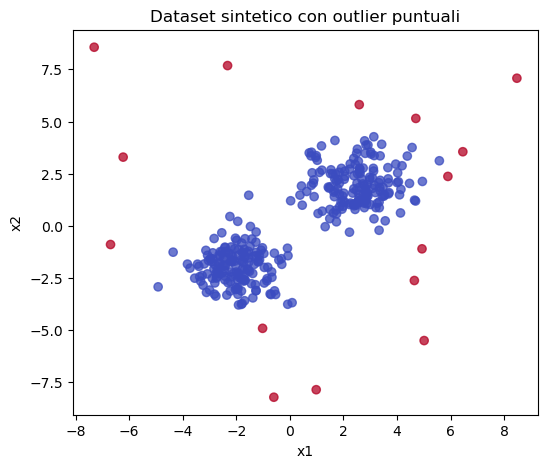

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(df["x1"], df["x2"], c=df["is_anomaly"], cmap="coolwarm", alpha=0.75)
plt.title("Dataset sintetico con outlier puntuali")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## 1.1 Metodo semplice: distanza euclidea dal centro

Idea:
1. stimiamo un centro dei dati
2. misuriamo la distanza di ogni punto da quel centro
3. i punti molto lontani vengono considerati anomali

In [4]:
center = df[["x1", "x2"]].mean().to_numpy()
df["euclidean_dist"] = np.sqrt((df["x1"] - center[0])**2 + (df["x2"] - center[1])**2)

threshold_euclid = df["euclidean_dist"].quantile(0.95)
df["pred_euclid"] = (df["euclidean_dist"] > threshold_euclid).astype(int)

print("Soglia distanza euclidea:", round(threshold_euclid, 3))
print(classification_report(df["is_anomaly"], df["pred_euclid"], target_names=["normale", "anomalia"]))
pd.DataFrame(
    confusion_matrix(df["is_anomaly"], df["pred_euclid"]),
    index=["true_normale", "true_anomalia"],
    columns=["pred_normale", "pred_anomalia"]
)

Soglia distanza euclidea: 5.106
              precision    recall  f1-score   support

     normale       0.99      0.99      0.99       320
    anomalia       0.76      0.87      0.81        15

    accuracy                           0.98       335
   macro avg       0.88      0.93      0.90       335
weighted avg       0.98      0.98      0.98       335



,pred_normale,pred_anomalia
true_normale,316,4
true_anomalia,2,13


## 1.2 MAD — Median Absolute Deviation

Il MAD è una misura **robusta** di dispersione:
\[
MAD = median(|x - median(x)|)
\]

Lo applichiamo a ciascuna feature e segnaliamo come anomalo
un punto che ha almeno una coordinata con `|modified_z| > 3.5`.

In [5]:
def mad(arr):
    med = np.median(arr)
    return np.median(np.abs(arr - med))

df_mad = df.copy()

for col in ["x1", "x2"]:
    med = np.median(df_mad[col])
    mad_val = mad(df_mad[col])
    df_mad[f"{col}_mad_z"] = 0.6745 * (df_mad[col] - med) / mad_val

df_mad["pred_mad"] = (
    (df_mad["x1_mad_z"].abs() > 3.5) |
    (df_mad["x2_mad_z"].abs() > 3.5)
).astype(int)

print(classification_report(df_mad["is_anomaly"], df_mad["pred_mad"], target_names=["normale", "anomalia"]))
pd.DataFrame(
    confusion_matrix(df_mad["is_anomaly"], df_mad["pred_mad"]),
    index=["true_normale", "true_anomalia"],
    columns=["pred_normale", "pred_anomalia"]
)

              precision    recall  f1-score   support

     normale       0.96      1.00      0.98       320
    anomalia       0.00      0.00      0.00        15

    accuracy                           0.96       335
   macro avg       0.48      0.50      0.49       335
weighted avg       0.91      0.96      0.93       335



c:\Users\gmorelli\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gmorelli\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gmorelli\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

,pred_normale,pred_anomalia
true_normale,320,0
true_anomalia,15,0


## 1.3 Isolation Forest

Isolation Forest isola i punti anomali più facilmente dei punti normali.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[["x1", "x2"]])

iso = IsolationForest(contamination=0.045, random_state=42)
pred_iso_raw = iso.fit_predict(X_scaled)
df["pred_iso"] = np.where(pred_iso_raw == -1, 1, 0)

print(classification_report(df["is_anomaly"], df["pred_iso"], target_names=["normale", "anomalia"]))
pd.DataFrame(
    confusion_matrix(df["is_anomaly"], df["pred_iso"]),
    index=["true_normale", "true_anomalia"],
    columns=["pred_normale", "pred_anomalia"]
)

              precision    recall  f1-score   support

     normale       1.00      1.00      1.00       320
    anomalia       0.94      1.00      0.97        15

    accuracy                           1.00       335
   macro avg       0.97      1.00      0.98       335
weighted avg       1.00      1.00      1.00       335



,pred_normale,pred_anomalia
true_normale,319,1
true_anomalia,0,15


In [7]:
summary_point = pd.DataFrame({
    "metodo": ["Distanza euclidea", "MAD", "Isolation Forest"],
    "precision_anomaly": [
        precision_score(df["is_anomaly"], df["pred_euclid"]),
        precision_score(df["is_anomaly"], df_mad["pred_mad"]),
        precision_score(df["is_anomaly"], df["pred_iso"]),
    ],
    "recall_anomaly": [
        recall_score(df["is_anomaly"], df["pred_euclid"]),
        recall_score(df["is_anomaly"], df_mad["pred_mad"]),
        recall_score(df["is_anomaly"], df["pred_iso"]),
    ],
    "f1_anomaly": [
        f1_score(df["is_anomaly"], df["pred_euclid"]),
        f1_score(df["is_anomaly"], df_mad["pred_mad"]),
        f1_score(df["is_anomaly"], df["pred_iso"]),
    ]
})
summary_point

c:\Users\gmorelli\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,metodo,precision_anomaly,recall_anomaly,f1_anomaly
0,Distanza euclidea,0.764706,0.866667,0.812500
1,MAD,0.000000,0.000000,0.000000
2,Isolation Forest,0.937500,1.000000,0.967742


# 2) Outlier contestuali nelle serie temporali

## Elementi tipici di una serie temporale
- **trend**: andamento di lungo periodo
- **stagionalità**: pattern che si ripete
- **rumore**: fluttuazione casuale
- **anomalie**: osservazioni che si discostano da quanto atteso

Un valore può essere “normale” in assoluto ma anomalo rispetto a:
- il periodo dell'anno
- l'ora del giorno
- la fase del ciclo
- il trend atteso

In [8]:
n = 365 * 2
t = np.arange(n)

trend = 0.01 * t
season = 8 * np.sin(2 * np.pi * t / 30)
noise = np.random.normal(0, 1.2, size=n)

y = 50 + trend + season + noise

context_idx = np.array([45, 46, 120, 210, 330, 500, 640])
y_context = y.copy()
y_context[context_idx] += np.array([12, -10, 14, -12, 13, -11, 15])

ts = pd.DataFrame({"ds_idx": t, "y": y_context})
ts["is_context_anomaly"] = 0
ts.loc[context_idx, "is_context_anomaly"] = 1
ts.head()

,ds_idx,y,is_context_anomaly
0,0,50.596057,0
1,1,51.507376,0
2,2,54.051119,0
3,3,56.559918,0
4,4,55.704175,0


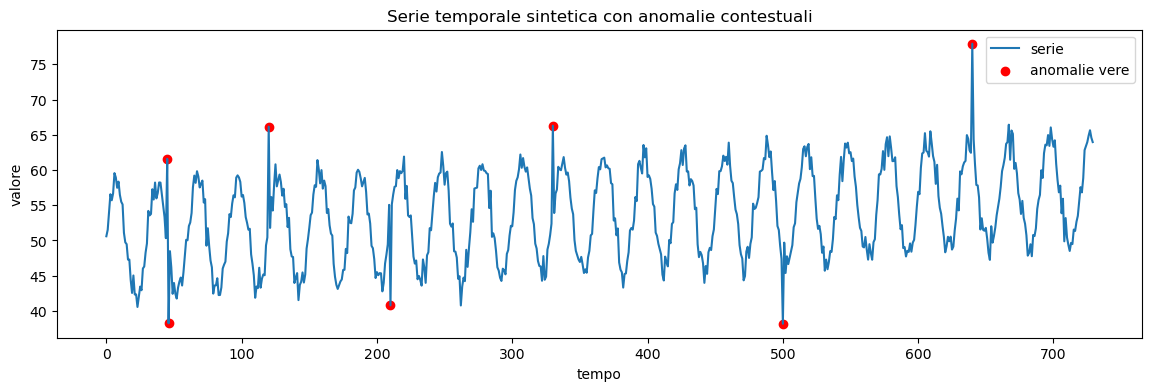

In [9]:
plt.figure(figsize=(14, 4))
plt.plot(ts["ds_idx"], ts["y"], label="serie")
plt.scatter(ts.loc[ts["is_context_anomaly"] == 1, "ds_idx"],
            ts.loc[ts["is_context_anomaly"] == 1, "y"],
            color="red", label="anomalie vere")
plt.title("Serie temporale sintetica con anomalie contestuali")
plt.xlabel("tempo")
plt.ylabel("valore")
plt.legend()
plt.show()

## 2.1 Baseline ingenua: z-score globale

In [10]:
mu = ts["y"].mean()
sigma = ts["y"].std()
ts["z_global"] = (ts["y"] - mu) / sigma
ts["pred_global"] = (ts["z_global"].abs() > 2.8).astype(int)

print(classification_report(ts["is_context_anomaly"], ts["pred_global"], target_names=["normale", "anomalia"]))
pd.DataFrame(
    confusion_matrix(ts["is_context_anomaly"], ts["pred_global"]),
    index=["true_normale", "true_anomalia"],
    columns=["pred_normale", "pred_anomalia"]
)

              precision    recall  f1-score   support

     normale       0.99      1.00      1.00       723
    anomalia       1.00      0.14      0.25         7

    accuracy                           0.99       730
   macro avg       1.00      0.57      0.62       730
weighted avg       0.99      0.99      0.99       730



,pred_normale,pred_anomalia
true_normale,723,0
true_anomalia,6,1


## 2.2 STL decomposition

**STL** = Seasonal-Trend decomposition using Loess

Separiamo la serie in:
- trend
- stagionalità
- residuo

Le anomalie contestuali dovrebbero emergere nei **residui**.

> Se `statsmodels` non fosse disponibile: `pip install statsmodels`

In [11]:
from statsmodels.tsa.seasonal import STL

stl = STL(ts["y"], period=30, robust=True)
res = stl.fit()

ts["trend_stl"] = res.trend
ts["seasonal_stl"] = res.seasonal
ts["resid_stl"] = res.resid

ts[["y", "trend_stl", "seasonal_stl", "resid_stl"]].head()

,y,trend_stl,seasonal_stl,resid_stl
0,50.596057,49.807796,0.252994,0.535267
1,51.507376,49.809116,1.846736,-0.148476
2,54.051119,49.810692,4.016607,0.223821
3,56.559918,49.812527,4.352793,2.394598
4,55.704175,49.814624,6.454396,-0.564846


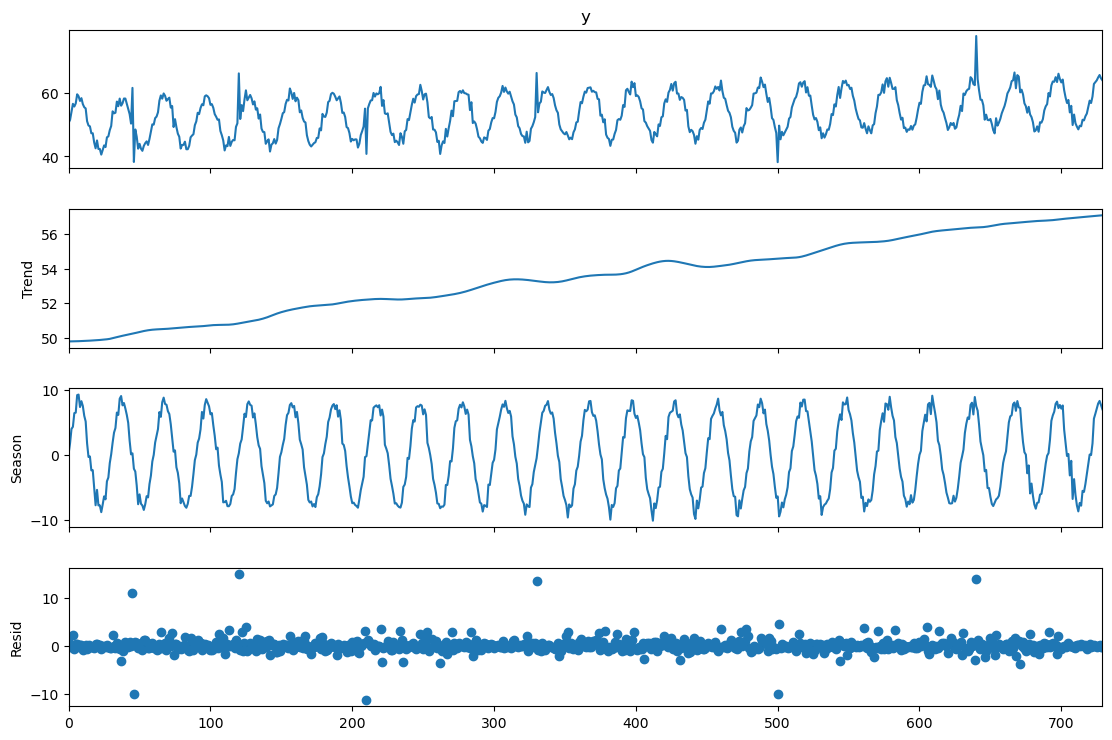

In [12]:
fig = res.plot()
fig.set_size_inches(12, 8)
plt.show()

In [13]:
resid_med = np.median(ts["resid_stl"])
resid_mad = np.median(np.abs(ts["resid_stl"] - resid_med))

ts["resid_stl_mz"] = 0.6745 * (ts["resid_stl"] - resid_med) / resid_mad
ts["pred_stl"] = (ts["resid_stl_mz"].abs() > 3.5).astype(int)

print(classification_report(ts["is_context_anomaly"], ts["pred_stl"], target_names=["normale", "anomalia"]))
pd.DataFrame(
    confusion_matrix(ts["is_context_anomaly"], ts["pred_stl"]),
    index=["true_normale", "true_anomalia"],
    columns=["pred_normale", "pred_anomalia"]
)

              precision    recall  f1-score   support

     normale       1.00      0.95      0.97       723
    anomalia       0.15      1.00      0.26         7

    accuracy                           0.95       730
   macro avg       0.58      0.97      0.62       730
weighted avg       0.99      0.95      0.97       730



,pred_normale,pred_anomalia
true_normale,684,39
true_anomalia,0,7


## 2.3 Prophet

**Prophet** è un modello additivo per serie temporali che rappresenta:
- trend
- stagionalità
- eventi / holiday (se presenti)

Nel nostro caso lo usiamo per modellare il comportamento atteso
e poi cercare anomalie nei residui.

> Se Prophet non fosse installato: `pip install prophet`

In [14]:
dates = pd.date_range("2023-01-01", periods=len(ts), freq="D")
ts_prophet = pd.DataFrame({
    "ds": dates,
    "y": ts["y"].values,
    "is_context_anomaly": ts["is_context_anomaly"].values
})
ts_prophet.head()

,ds,y,is_context_anomaly
0,2023-01-01,50.596057,0
1,2023-01-02,51.507376,0
2,2023-01-03,54.051119,0
3,2023-01-04,56.559918,0
4,2023-01-05,55.704175,0


In [15]:
try:
    from prophet import Prophet
    prophet_available = True
except Exception as e:
    prophet_available = False
    print("Prophet non disponibile. Installa con: pip install prophet")
    print("Errore:", e)

Prophet non disponibile. Installa con: pip install prophet
Errore: No module named 'prophet'


In [16]:
if prophet_available:
    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=False
    )
    m.add_seasonality(name="monthly", period=30.5, fourier_order=5)
    m.fit(ts_prophet[["ds", "y"]])

    forecast = m.predict(ts_prophet[["ds"]])
    ts_prophet["yhat"] = forecast["yhat"].values
    ts_prophet["resid_prophet"] = ts_prophet["y"] - ts_prophet["yhat"]

    med_p = np.median(ts_prophet["resid_prophet"])
    mad_p = np.median(np.abs(ts_prophet["resid_prophet"] - med_p))
    ts_prophet["mz_prophet"] = 0.6745 * (ts_prophet["resid_prophet"] - med_p) / mad_p
    ts_prophet["pred_prophet"] = (ts_prophet["mz_prophet"].abs() > 3.5).astype(int)

    print(classification_report(ts_prophet["is_context_anomaly"], ts_prophet["pred_prophet"], target_names=["normale", "anomalia"]))
    print(pd.DataFrame(
        confusion_matrix(ts_prophet["is_context_anomaly"], ts_prophet["pred_prophet"]),
        index=["true_normale", "true_anomalia"],
        columns=["pred_normale", "pred_anomalia"]
    ))
else:
    print("Salta questa parte oppure installa prophet.")

Salta questa parte oppure installa prophet.


# 3) Outlier multivariati e collettivi

## 3.1 Correlazione anomala tra misure
Due variabili possono essere normalmente molto correlate.
Un punto che rompe questa relazione può essere anomalo anche se i singoli valori non sono estremi.

In [17]:
n_corr = 250
m1 = np.random.normal(50, 8, size=n_corr)
m2 = 2.2 * m1 + np.random.normal(0, 4, size=n_corr)

m1_out = np.array([42, 48, 55, 61, 67, 73, 58, 46])
m2_out = np.array([120, 20, 135, 35, 150, 40, 130, 25])

m1_all = np.concatenate([m1, m1_out])
m2_all = np.concatenate([m2, m2_out])
y_corr = np.array([0] * n_corr + [1] * len(m1_out))

corr_df = pd.DataFrame({"m1": m1_all, "m2": m2_all, "is_anomaly": y_corr})
corr_df.head()

,m1,m2,is_anomaly
0,51.566762,116.590077,0
1,42.173018,94.482469,0
2,53.266022,113.317344,0
3,36.379331,79.843683,0
4,58.233245,128.098729,0


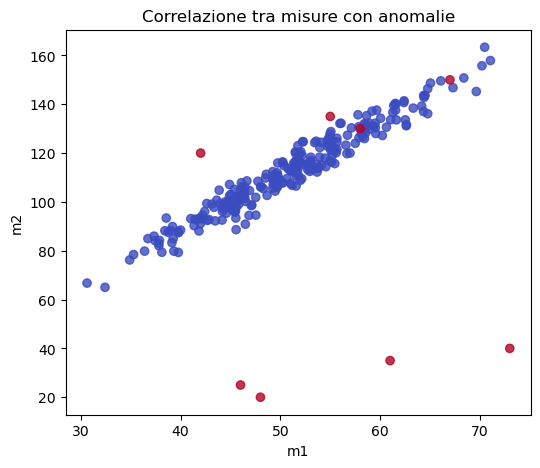

In [18]:
plt.figure(figsize=(6, 5))
plt.scatter(corr_df["m1"], corr_df["m2"], c=corr_df["is_anomaly"], cmap="coolwarm", alpha=0.8)
plt.title("Correlazione tra misure con anomalie")
plt.xlabel("m1")
plt.ylabel("m2")
plt.show()

### Idea semplice: residui rispetto a una relazione lineare

Stimiamo una relazione `m2 ~ m1` e guardiamo i residui.
Punti con residui molto grandi possono essere anomalie.

In [19]:
coef = np.polyfit(corr_df["m1"], corr_df["m2"], deg=1)
a, b = coef[0], coef[1]
corr_df["m2_hat"] = a * corr_df["m1"] + b
corr_df["resid"] = corr_df["m2"] - corr_df["m2_hat"]

med_r = np.median(corr_df["resid"])
mad_r = np.median(np.abs(corr_df["resid"] - med_r))
corr_df["resid_mz"] = 0.6745 * (corr_df["resid"] - med_r) / mad_r
corr_df["pred_resid"] = (corr_df["resid_mz"].abs() > 3.5).astype(int)

print(classification_report(corr_df["is_anomaly"], corr_df["pred_resid"], target_names=["normale", "anomalia"]))
pd.DataFrame(
    confusion_matrix(corr_df["is_anomaly"], corr_df["pred_resid"]),
    index=["true_normale", "true_anomalia"],
    columns=["pred_normale", "pred_anomalia"]
)

              precision    recall  f1-score   support

     normale       0.99      1.00      0.99       250
    anomalia       1.00      0.62      0.77         8

    accuracy                           0.99       258
   macro avg       0.99      0.81      0.88       258
weighted avg       0.99      0.99      0.99       258



,pred_normale,pred_anomalia
true_normale,250,0
true_anomalia,3,5


## 3.2 Outlier collettivi: segmenti anomali in una serie

Costruiamo una serie con stagionalità normale e inseriamo un segmento
con comportamento anomalo. Poi trasformiamo la serie in **finestre mobili**.

In [20]:
n2 = 320
t2 = np.arange(n2)

base = 10 + 3*np.sin(2*np.pi*t2/28) + np.random.normal(0, 0.6, size=n2)
y2 = base.copy()

collective_start, collective_end = 180, 220
y2[collective_start:collective_end] = (
    np.linspace(4, 15, collective_end - collective_start)
    + np.random.normal(0, 0.3, size=collective_end - collective_start)
)

ts2 = pd.DataFrame({"t": t2, "value": y2})
ts2["is_collective_anomaly"] = 0
ts2.loc[collective_start:collective_end-1, "is_collective_anomaly"] = 1
ts2.head()

,t,value,is_collective_anomaly
0,0,9.665505,0
1,1,9.845681,0
2,2,11.248682,0
3,3,13.418295,0
4,4,11.863290,0


In [21]:
window = 20
rows = []

for start in range(0, len(ts2) - window + 1):
    end = start + window
    w = ts2["value"].iloc[start:end].to_numpy()
    x = np.arange(window)
    slope = np.polyfit(x, w, 1)[0]

    rows.append({
        "start": start,
        "end": end,
        "mean": w.mean(),
        "std": w.std(),
        "range": w.max() - w.min(),
        "slope": slope,
        "is_collective_window": int(ts2["is_collective_anomaly"].iloc[start:end].mean() > 0.5)
    })

win_df = pd.DataFrame(rows)
win_df.head()

,start,end,mean,std,range,slope,is_collective_window
0,0,20,10.845204,2.221216,7.567848,-0.245725,0
1,1,21,10.725616,2.342580,7.567848,-0.315373,0
2,2,22,10.608338,2.440370,7.567848,-0.375345,0
3,3,23,10.339852,2.642189,8.052429,-0.432796,0
4,4,24,10.045014,2.611042,8.052429,-0.424451,0


In [22]:
X_win = win_df[["mean", "std", "range", "slope"]]
X_win_s = StandardScaler().fit_transform(X_win)

iso_win = IsolationForest(contamination=0.15, random_state=42)
pred_win_raw = iso_win.fit_predict(X_win_s)
win_df["pred_collective_window"] = np.where(pred_win_raw == -1, 1, 0)

print(classification_report(win_df["is_collective_window"], win_df["pred_collective_window"], target_names=["normale", "anomalia"]))
pd.DataFrame(
    confusion_matrix(win_df["is_collective_window"], win_df["pred_collective_window"]),
    index=["true_normale", "true_anomalia"],
    columns=["pred_normale", "pred_anomalia"]
)

              precision    recall  f1-score   support

     normale       0.93      0.91      0.92       262
    anomalia       0.47      0.54      0.50        39

    accuracy                           0.86       301
   macro avg       0.70      0.72      0.71       301
weighted avg       0.87      0.86      0.86       301



,pred_normale,pred_anomalia
true_normale,238,24
true_anomalia,18,21


# 4) Sintesi finale

## Cosa abbiamo visto

### Outlier puntuali
- distanza euclidea
- MAD / modified z-score
- Isolation Forest

### Outlier contestuali
- una serie temporale non va letta solo “globalmente”
- STL e Prophet permettono di modellare trend e stagionalità
- l’anomalia emerge spesso nei residui

### Outlier multivariati / collettivi
- una relazione tra variabili può rompersi
- un segmento può essere anomalo nel suo insieme
- spesso bisogna cambiare rappresentazione (es. finestre mobili)

## Messaggio chiave
Non basta chiedersi:
> “Quale algoritmo uso?”

Bisogna chiedersi prima:
> “Che cosa significa, in questo problema, essere anomali?”